<h2 align="center" style="color:#4169E1;">
  Vehicle Damage Detection Project
</h2>

## Importing Libraries

In [17]:
import os
from torchvision import datasets,transforms
import torch 
import torch.nn as nn 
import torch.optim as optim
import torch.nn.functional as F 
import torchvision.models as models
from torch.utils.data import DataLoader,random_split
import time
import matplotlib.pyplot as plt

In [18]:
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## Load Data

In [19]:
img_transforms=transforms.Compose(
    [
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2,contrast=0.2,saturation=0.2),
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize(
                                mean = [0.485, 0.456, 0.406],
                                std  = [0.229, 0.224, 0.225]
                            )
    ]
)

In [20]:
path=".\dataset"
dataset=datasets.ImageFolder(root=path,transform=img_transforms)
len(dataset)

2300

In [21]:
classes=dataset.classes
classes

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [22]:
num_classes=len(classes)
num_classes

6

In [23]:
train_size=int(0.75*len(dataset))
val_size=len(dataset)-train_size

train_size,val_size

(1725, 575)

In [24]:
train_dataset,val_dataset=random_split(dataset,[train_size,val_size])

In [25]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=32,shuffle=True)


In [26]:
for images,labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [28]:
images[0].shape

torch.Size([3, 224, 224])

In [31]:
images[0].permute(1,2,0).shape

torch.Size([224, 224, 3])

In [39]:
classes[labels[0]]

'F_Normal'

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.5005665].


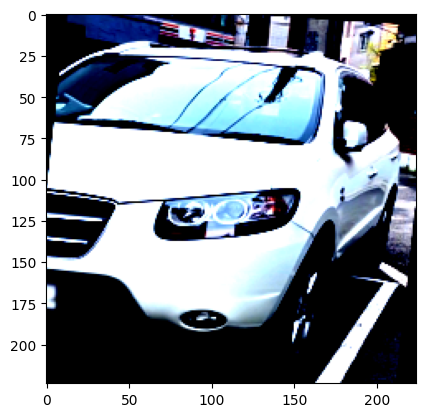

In [40]:
plt.imshow(images[0].permute(1,2,0))
plt.show()

## Model 1 : CNN

In [41]:
class CarClassifierCNN(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.network=nn.Sequential(
            nn.Conv2d(in_channels=3,out_channels=16,kernel_size=3,stride=1,padding=1), #(16,224,224)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0), #(16,112,112)
            nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3,stride=1,padding=1), #(32,112,112)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0), #(32,56,56)
            nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,stride=1,padding=1), #(64,56,56)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0),    #(64,28,28)
            nn.Flatten(),

            nn.Linear(64*28*28,512),
            nn.ReLU(),
            nn.Linear(512,num_classes)     

        )
    def forward(self,x):
        return self.network(x)

In [44]:
CarClassifierCNN(num_classes)

CarClassifierCNN(
  (network): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=50176, out_features=512, bias=True)
    (11): ReLU()
    (12): Linear(in_features=512, out_features=6, bias=True)
  )
)

In [46]:
def train_model(model, criterion, optimizer, epochs=5):
    start = time.time()
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_num, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
            if (batch_num+1) % 10 == 0:
                print(f"Batch: {batch_num+1}, Epoch: {epoch+1}, Loss: {loss.item():0.2f}")
            
            running_loss += loss.item() * images.size(0)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch [{epoch+1}/{epochs}], Avg Loss: {epoch_loss:.4f}")

        # Validation
        model.eval()
        correct = 0
        total = 0
        all_labels = []
        all_predictions = []
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data,1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())
                
            print(f"*** Validation Accuracy: {100 * correct / total:.2f}% ***")
            
    end = time.time()
    print(f"Execution time: {end - start} seconds")     
    
    return all_labels, all_predictions

In [47]:
# Instantiate the model, loss function, and optimizer
model = CarClassifierCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

all_labels, all_predictions = train_model(model, criterion, optimizer, epochs=10)

Batch: 10, Epoch: 1, Loss: 1.78
Batch: 20, Epoch: 1, Loss: 1.79
Batch: 30, Epoch: 1, Loss: 1.71
Batch: 40, Epoch: 1, Loss: 1.66
Batch: 50, Epoch: 1, Loss: 1.60
Epoch [1/10], Avg Loss: 2.0095
*** Validation Accuracy: 39.13% ***
Batch: 10, Epoch: 2, Loss: 1.46
Batch: 20, Epoch: 2, Loss: 1.42
Batch: 30, Epoch: 2, Loss: 1.46
Batch: 40, Epoch: 2, Loss: 1.18
Batch: 50, Epoch: 2, Loss: 1.22
Epoch [2/10], Avg Loss: 1.3616
*** Validation Accuracy: 51.30% ***
Batch: 10, Epoch: 3, Loss: 1.19
Batch: 20, Epoch: 3, Loss: 1.09
Batch: 30, Epoch: 3, Loss: 1.47
Batch: 40, Epoch: 3, Loss: 1.34
Batch: 50, Epoch: 3, Loss: 1.38
Epoch [3/10], Avg Loss: 1.2102
*** Validation Accuracy: 48.70% ***
Batch: 10, Epoch: 4, Loss: 1.24
Batch: 20, Epoch: 4, Loss: 0.99
Batch: 30, Epoch: 4, Loss: 0.87
Batch: 40, Epoch: 4, Loss: 0.88
Batch: 50, Epoch: 4, Loss: 0.88
Epoch [4/10], Avg Loss: 1.0372
*** Validation Accuracy: 54.43% ***
Batch: 10, Epoch: 5, Loss: 1.05
Batch: 20, Epoch: 5, Loss: 1.05
Batch: 30, Epoch: 5, Loss: 0

#### Here, the Training Loss is Reduced almost to zero , But the validation Accuracy isn't improved that Great! Hence we can say that the model may be overfitting! so, we use some regularization techniques to see some improvements 

In [48]:
class CarClassifierCNN(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.network=nn.Sequential(
            nn.Conv2d(in_channels=3,out_channels=16,kernel_size=3,stride=1,padding=1), #(16,224,224)
            nn.BatchNorm2d(16), #batch Normalization
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0), #(16,112,112)
            nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3,stride=1,padding=1), #(32,112,112)
            nn.BatchNorm2d(32),#batch Normalization
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0), #(32,56,56)
            nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,stride=1,padding=1), #(64,56,56)
            nn.BatchNorm2d(64), #batch Normalization
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0),    #(64,28,28)
            nn.Flatten(),

            nn.Linear(64*28*28,512),
            nn.ReLU(),
            nn.Dropout(0.5), #Dropout Regularization
            nn.Linear(512,num_classes)     

        )
    def forward(self,x):
        return self.network(x)

In [ ]:
# Instantiate the model, loss function, and optimizer
model = CarClassifierCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

all_labels, all_predictions = train_model(model, criterion, optimizer, epochs=10)

Batch: 10, Epoch: 1, Loss: 15.13
Batch: 20, Epoch: 1, Loss: 4.84
Batch: 30, Epoch: 1, Loss: 2.17
Batch: 40, Epoch: 1, Loss: 1.79
Batch: 50, Epoch: 1, Loss: 1.65


#### Here Regualrization won't help in solving our problem! it may be happened due to the Less availability of data! 
#### It is the usual scenario we will seen in most real life cases because acquiring the large amount of data can costs more time and price , Hence we can use the transfer learning for such sceanarios 